# Bronze Layer — Raw VOD / Screenshot Preprocessing

Welcome to the **Bronze layer** of the Game State Vision Predictor.

## Where Are We in the Pipeline?

```

Raw Screenshot ─┐

                ├──► [BRONZE] ──► [SILVER] ──► [GOLD] ──► Prediction

Match VOD ─────┘    (you are here)   (OCR)      (model)

```

The Bronze layer is the **entry point**. It ingests two kinds of input **uniformly**:

1. **Single screenshots** — the zero-friction "state check" demo.

2. **Multi-minute match VODs** — the full product: frames are sampled from the

   video at a regular interval, and each sample runs the exact same OpenCV

   pipeline (denoise → contrast → sharpen) as a screenshot.

Everything that leaves this layer obeys the **shape contract** `(H=1440, W=2560, 3)

and carries a per-frame metadata sidecar, so Silver never needs to know which

kind of input produced the frame.

## What This Notebook Will Show

1. Discover inputs (screenshots *and* VODs)

2. Screenshot path: load, validate, preprocess, visualize, metadata

3. VOD path: inspect the source, sample raw frames, run the full single-pass pipeline

4. Graceful failure: what happens with an over-long VOD

5. Visual preview of what the Silver layer will actually receive

---

In [1]:
import sys
from pathlib import Path

# Resolve the project root no matter where the notebook is launched from.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from src.config import BRONZE_DIR, SILVER_DIR
from src.ingestor_bronze import (
    VIDEO_EXTENSIONS,
    H,
    W,
    extract_frames,
    get_vod_info,
    load_image,
    preprocess,
    process_image,
    process_vod,
    validate_vod_duration,
)

sns.set_theme(style="darkgrid")
%matplotlib inline
        

## 1. Discover Inputs

`data/bronze/` is the drop zone. We scan it for screenshots (`*.png`) and VODs
(`.mp4`, `.mov`, `.avi`, `.mkv`, ...). If no real VOD is present yet, we
synthesize a short demo VOD so the whole VOD path can be walked end to end.
            

In [2]:
screenshots = sorted(BRONZE_DIR.glob("*.png"))
vods = sorted(p for p in BRONZE_DIR.iterdir() if p.suffix.lower() in VIDEO_EXTENSIONS)

print(f"Screenshots found : {len(screenshots)}")
print(f"VODs found        : {len(vods)}")

if not screenshots:
    raise FileNotFoundError(
        "No PNG screenshots in data/bronze/. Drop one in and restart the notebook."
    )

image_path = screenshots[0]
print(f"Using screenshot: {image_path.name}")
            

Screenshots found : 2
VODs found        : 0
Using screenshot: Screenshot 2026-07-25 112239.png


### 1.1 Demo VOD (only if no real VOD is available)

The demo VOD is a short 30 fps clip of labeled black frames at desktop
resolution. It drives the same code path as a real multi-minute match VOD —
only shorter, so this notebook stays quick.
            

In [3]:
DEMO_DIR = PROJECT_ROOT / "outputs" / "bronze_demo"
DEMO_DIR.mkdir(parents=True, exist_ok=True)
DEMO_VOD = DEMO_DIR / "demo_vod.mp4"

if vods:
    vod_path = vods[0]
    print(f"Using real VOD: {vod_path.name}")
else:
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(str(DEMO_VOD), fourcc, 30.0, (W, H))
    for i in range(90):
        frame = np.zeros((H, W, 3), dtype=np.uint8)
        cv2.putText(frame, f"Frame {i}", (100, 100),
                    cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 255), 3)
        out.write(frame)
    out.release()
    vod_path = DEMO_VOD
    print(f"Synthesized demo VOD: {vod_path.name}")
            

Synthesized demo VOD: demo_vod.mp4


## 2. Screenshot Path — Load & Validate

`load_image()` reads a raw screenshot and enforces the **shape contract**
`(H=1440, W=2560, 3)`. Mismatched dimensions are silently resized so downstream
code never sees a surprise.
            

In [4]:
raw = load_image(image_path)

print(f"Shape  : {raw.shape}")
print(f"Dtype  : {raw.dtype}")
print(f"Min/Max: {raw.min()} / {raw.max()}")
print(f"Aspect : {raw.shape[1] / raw.shape[0]:.2f} (16:9 = 1.78)")
            

Shape  : (1440, 2560, 3)
Dtype  : uint8
Min/Max: 0 / 255
Aspect : 1.78 (16:9 = 1.78)


## 3. Why Preprocess? — The "Why" Behind Each Step

Raw game frames contain **compression noise and soft edges** that confuse
downstream OCR and models. Bronze applies three stages:

| Step | Method | Purpose |

|------|--------|---------|

| 1. Denoise | Non-Local Means | Remove compression noise while preserving edges |
| 2. Contrast | CLAHE on L-channel | Boost local contrast (health bars, icons) without amplifying noise |
| 3. Sharpen | Unsharp mask | Restore edge definition softened by denoising |

Let's look at each stage side by side.
            

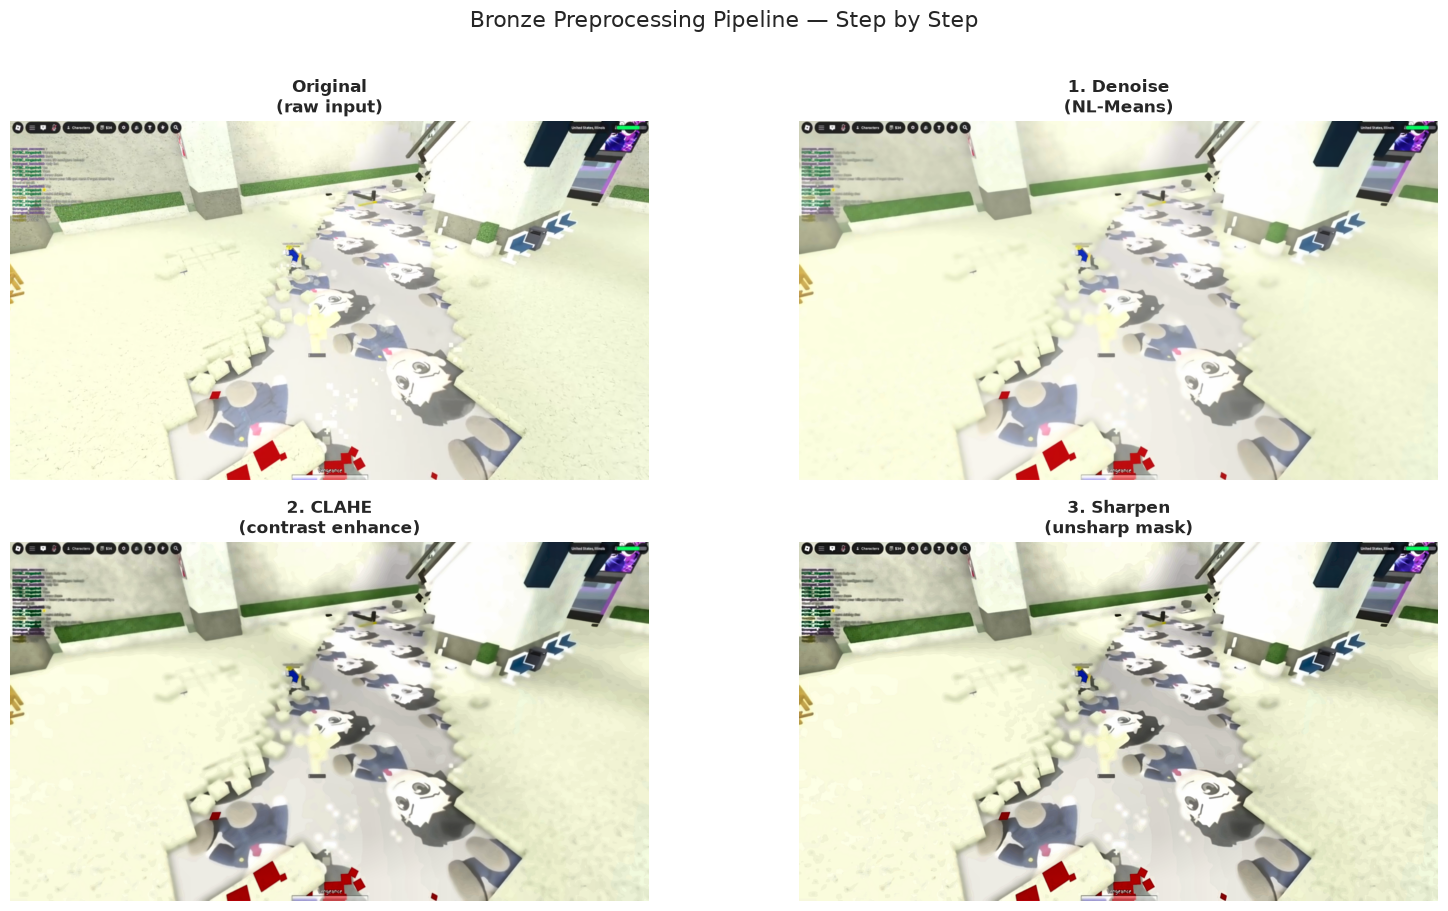

In [5]:
from src.ingestor_bronze import denoise, enhance_contrast

stages = {
    "Original\n(raw input)": raw,
    "1. Denoise\n(NL-Means)": denoise(raw),
    "2. CLAHE\n(contrast enhance)": enhance_contrast(denoise(raw)),
    "3. Sharpen\n(unsharp mask)": preprocess(raw),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, (title, img) in zip(axes.ravel(), stages.items()):
    ax.imshow(img)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")
fig.suptitle("Bronze Preprocessing Pipeline — Step by Step", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()
            

## 4. Where Did the Pipeline Change the Image?

The absolute per-pixel difference between raw and preprocessed input. Brighter
regions mean more aggressive modification.
            

Mean per-pixel change : 13.52
Max  per-pixel change : 114


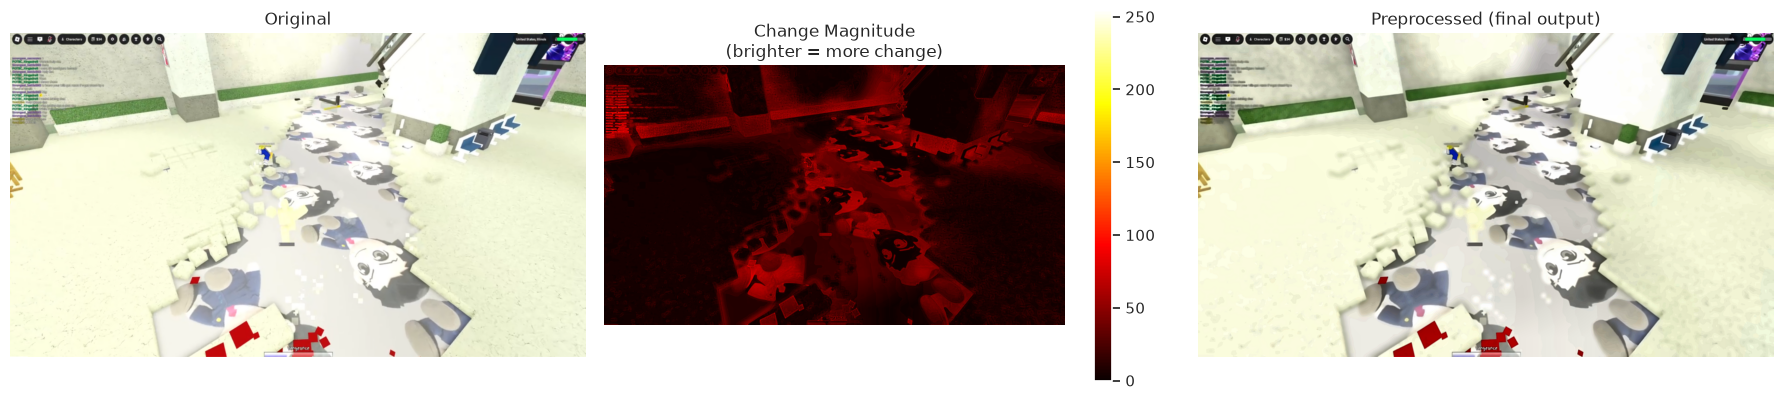

In [6]:
cleaned = preprocess(raw)
diff = np.abs(raw.astype(np.int16) - cleaned.astype(np.int16)).astype(np.uint8)
diff_gray = diff.max(axis=2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(raw)
axes[0].set_title("Original")
axes[0].axis("off")
im = axes[1].imshow(diff_gray, cmap="hot", vmin=0, vmax=255)
axes[1].set_title("Change Magnitude\n(brighter = more change)")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], shrink=0.8)
axes[2].imshow(cleaned)
axes[2].set_title("Preprocessed (final output)")
axes[2].axis("off")

print(f"Mean per-pixel change : {diff.mean():.2f}")
print(f"Max  per-pixel change : {diff.max()}")
plt.tight_layout()
plt.show()
            

### 4.1 RGB Histogram — Before vs After

The CLAHE step stretches the histogram, spreading the 0–255 range more evenly
and improving contrast in dark or mid-tone regions.
            

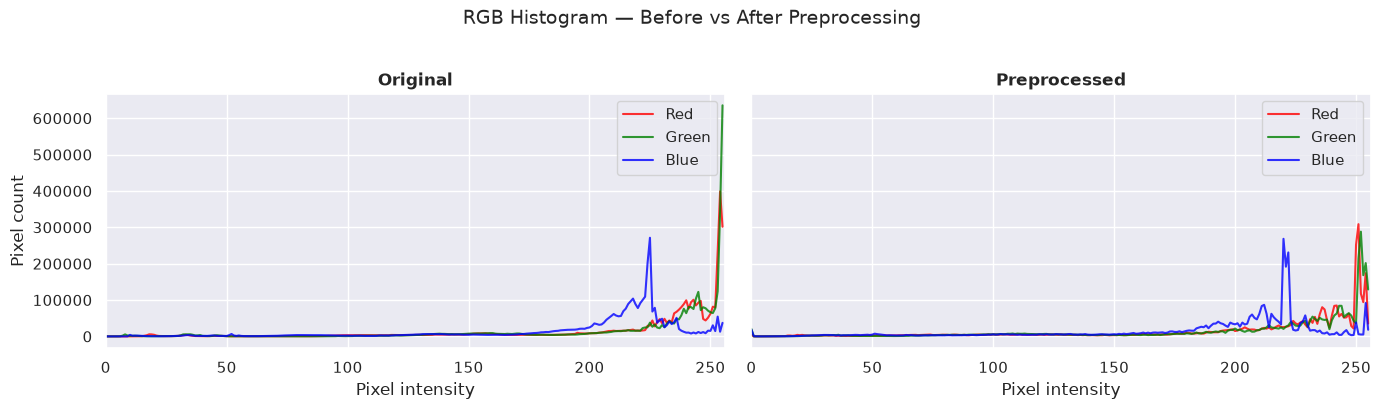

In [7]:
colors = ("Red", "Green", "Blue")
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for i, (img, title) in enumerate([(raw, "Original"), (cleaned, "Preprocessed")]):
    ax = axes[i]
    for c, color_name in enumerate(colors):
        hist = cv2.calcHist([img], [c], None, [256], [0, 256])
        ax.plot(hist, color=color_name.lower(), label=color_name, alpha=0.8)
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(0, 256)
    ax.set_xlabel("Pixel intensity")
    if i == 0:
        ax.set_ylabel("Pixel count")
    ax.legend()

fig.suptitle("RGB Histogram — Before vs After Preprocessing", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
            

## 5. Screenshot Metadata & Artifacts

`process_image()` runs the whole screenshot path in one call and writes two
artifacts to disk: the cleaned PNG and a metadata JSON. These are the inputs
the Silver layer consumes.
            

In [8]:
result_image = process_image(str(image_path), str(SILVER_DIR))

print(f"Preprocessed PNG : {result_image['preprocessed']}")
print(f"Metadata JSON    : {result_image['metadata']}")

with open(result_image["metadata"]) as f:
    saved_meta = json.load(f)
print(f"\nMetadata keys: {list(saved_meta.keys())}")
            

Preprocessed PNG : /mnt/c/Users/Ryan Craft/Documents/Coding/Game State Vision Predictor/data/silver/Screenshot 2026-07-25 112239_bronze.png
Metadata JSON    : /mnt/c/Users/Ryan Craft/Documents/Coding/Game State Vision Predictor/data/silver/Screenshot 2026-07-25 112239_bronze.json

Metadata keys: ['image_path', 'frame_index', 'timestamp_sec', 'mean_brightness', 'std_brightness', 'contrast', 'width', 'height', 'channels']


## 6. VOD Path — Inspect the Source

Unlike a screenshot, a VOD is a container we must open before anything else.
`get_vod_info()` reads its duration, fps, frame count and resolution without
decoding a single frame.
            

In [9]:
vod_info = get_vod_info(str(vod_path))

print("VOD metadata:")
for key, value in vod_info.__dict__.items():
    print(f"  {key:12s}: {value}")
            

VOD metadata:
  vod_path    : /mnt/c/Users/Ryan Craft/Documents/Coding/Game State Vision Predictor/outputs/bronze_demo/demo_vod.mp4
  duration_sec: 3.0
  fps         : 30.0
  total_frames: 90
  width       : 2560
  height      : 1440
  frame_interval: 1
  extracted_frames: 0


## 7. VOD Path — Duration Guard

VODs over ~15 minutes fail **gracefully** (a clear `ValueError`) instead of
melting the disk or the pipeline. Below the limit, sampling proceeds normally.
            

In [10]:
from src.ingestor_bronze import MAX_VOD_DURATION_SEC

try:
    validate_vod_duration(vod_info)
    print(f"OK: {vod_info.duration_sec:.1f}s is within the "
          f"{MAX_VOD_DURATION_SEC // 60}-minute limit.")
except ValueError as exc:
    print(f"Blocked: {exc}")
            

OK: 3.0s is within the 15-minute limit.


### 7.1 Expected bad input — an over-long VOD

We synthesize a VOD whose duration exceeds the limit (tiny frames, so it builds
in a fraction of a second). Reading its metadata and validating it fails the
Bronze layer cleanly — no partial output, no crash.
            

In [11]:
long_vod_path = DEMO_DIR / "long_vod.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(str(long_vod_path), fourcc, 30.0, (64, 48))
for _ in range(30 * 910):  # 910s > 900s limit, at tiny 64x48 frames
    out.write(np.zeros((48, 64, 3), dtype=np.uint8))
out.release()

try:
    info = get_vod_info(str(long_vod_path))
    validate_vod_duration(info)
    print("Unexpected: over-limit VOD passed.")
except ValueError as exc:
    print(f"Gracefully blocked: {exc}")
            

Gracefully blocked: VOD duration 910.0s exceeds maximum of 900s (15 minutes)


## 8. VOD Path — Raw Frame Sampling

`extract_frames()` steps through the VOD once and saves the **raw** sampled
frames (standardized to the (H, W, 3) contract, but not preprocessed). Use this
when you want to eyeball source frames before spending preprocessing compute on
them. The output shows the timeline positions that will be analyzed.
            

In [12]:
raw_dir = DEMO_DIR / "raw_frames"
raw_frames = extract_frames(str(vod_path), str(raw_dir), frame_interval=15)

print(f"Extracted {len(raw_frames)} raw frames (every 15th frame "
      f"= every {15 / vod_info.fps:.2f}s of gameplay)")
for frame in raw_frames[:5]:
    print(f"  frame {frame['frame_index']:4d} @ {frame['timestamp_sec']:.2f}s "
          f"-> {Path(frame['image_path']).name}")
            

Extracted 6 raw frames (every 15th frame = every 0.50s of gameplay)
  frame    0 @ 0.00s -> demo_vod_frame_000000.png
  frame   15 @ 0.50s -> demo_vod_frame_000015.png
  frame   30 @ 1.00s -> demo_vod_frame_000030.png
  frame   45 @ 1.50s -> demo_vod_frame_000045.png
  frame   60 @ 2.00s -> demo_vod_frame_000060.png


## 9. VOD Path — Full Bronze Pipeline (Single Pass)

`process_vod()` is the workhorse: sample → standardize → preprocess → save.
Every sampled frame is written exactly once, as a `_bronze.png` plus a metadata
sidecar, alongside a VOD-level metadata JSON. There are no raw intermediate
frames left on disk — for a multi-minute VOD this is the difference between
tens of thousands of stray PNGs and a clean artifact set.
            

In [13]:
bronze_dir = DEMO_DIR / "bronze_frames"
vod_result = process_vod(
    str(vod_path), str(bronze_dir),
    frame_interval=15,          # match a real multi-minute cadence
    max_frames=6,               # cap so this demo notebook stays fast
)

frames = vod_result["frames"]
print(f"Processed {len(frames)} bronze frames from "
      f"{vod_result['vod_metadata']['duration_sec']:.1f}s of video")
print(f"VOD metadata JSON : {vod_result['vod_metadata_path']}")

for frame in frames:
    print(f"  frame {frame['frame_index']:4d} @ {frame['timestamp_sec']:.2f}s "
          f"-> {Path(frame['preprocessed']).name}  ({Path(frame['metadata']).name})")
            

Processed 6 bronze frames from 3.0s of video
VOD metadata JSON : /mnt/c/Users/Ryan Craft/Documents/Coding/Game State Vision Predictor/outputs/bronze_demo/bronze_frames/demo_vod_vod_metadata.json
  frame    0 @ 0.00s -> demo_vod_frame_000000_bronze.png  (demo_vod_frame_000000_bronze.json)
  frame   15 @ 0.50s -> demo_vod_frame_000015_bronze.png  (demo_vod_frame_000015_bronze.json)
  frame   30 @ 1.00s -> demo_vod_frame_000030_bronze.png  (demo_vod_frame_000030_bronze.json)
  frame   45 @ 1.50s -> demo_vod_frame_000045_bronze.png  (demo_vod_frame_000045_bronze.json)
  frame   60 @ 2.00s -> demo_vod_frame_000060_bronze.png  (demo_vod_frame_000060_bronze.json)
  frame   75 @ 2.50s -> demo_vod_frame_000075_bronze.png  (demo_vod_frame_000075_bronze.json)


## 10. What the Silver Layer Will Receive

A preview of the bronze frames, in timeline order, with their timestamps. This
is the exact input the Silver layer's HUD-grounding OCR reads from.
            

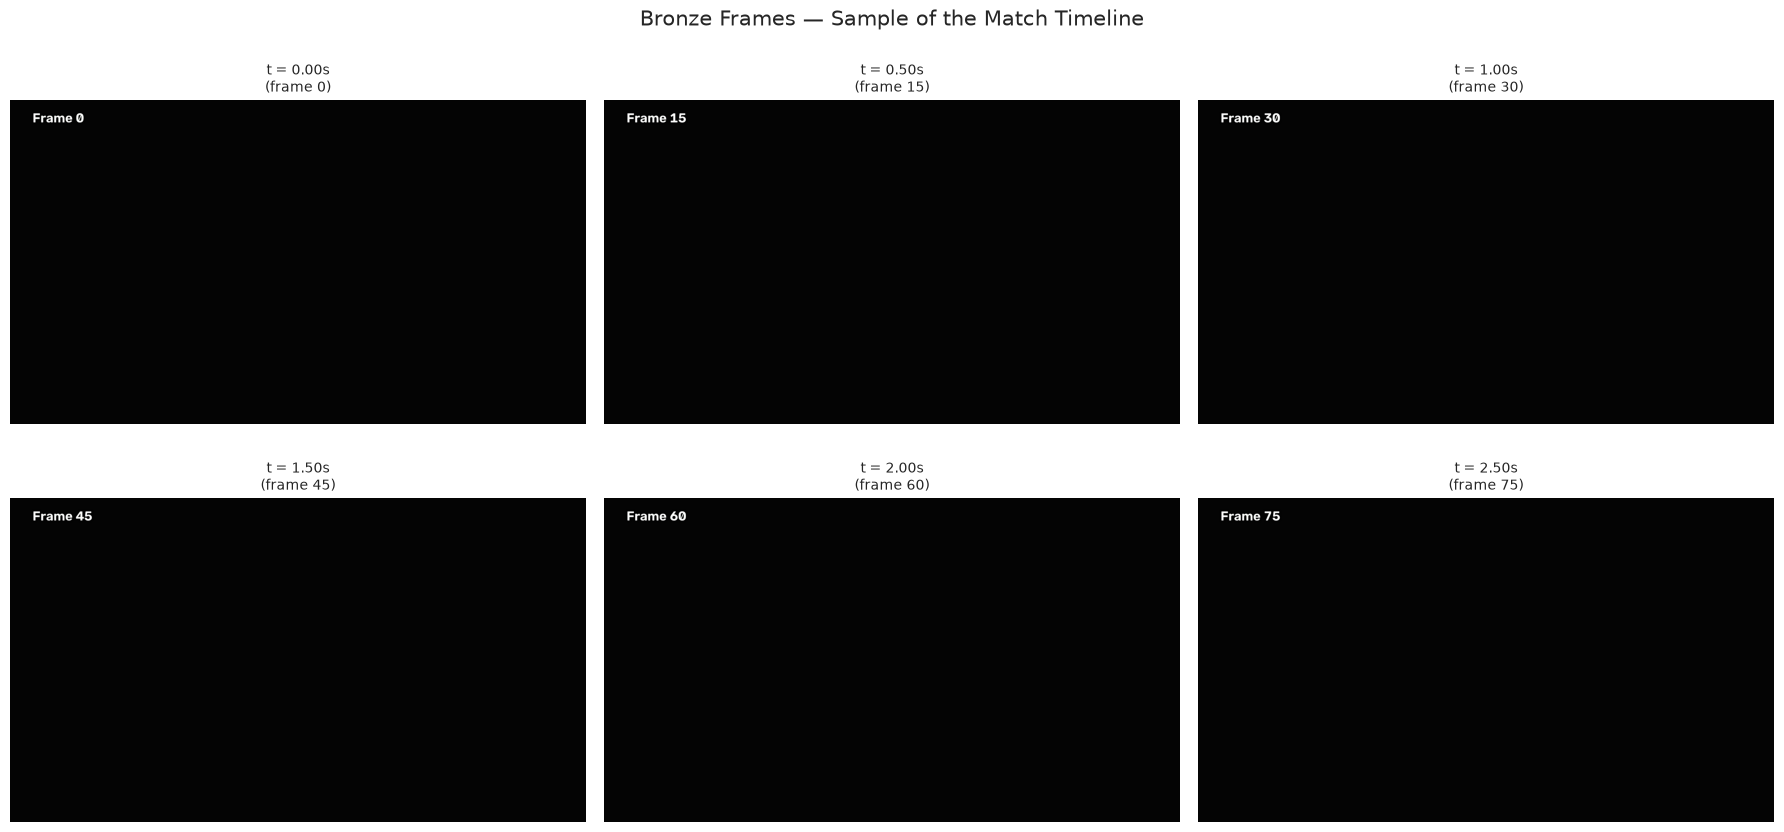

In [14]:
preview_count = len(frames)
cols = 3
rows = int(np.ceil(preview_count / cols))
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4.5))
axes = np.atleast_1d(axes).ravel()

for ax, frame in zip(axes, frames):
    img = cv2.cvtColor(cv2.imread(frame["preprocessed"]), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"t = {frame['timestamp_sec']:.2f}s\n"
                 f"(frame {frame['frame_index']})", fontsize=10)
    ax.axis("off")

for ax in axes[len(frames):]:
    ax.axis("off")

fig.suptitle("Bronze Frames — Sample of the Match Timeline", fontsize=15)
plt.tight_layout()
plt.show()
            

## 11. Per-Frame Metadata Sidecar

Each bronze frame carries a JSON sidecar with brightness/contrast statistics
plus its timeline position. The Silver layer uses the timeline position to
aggregate per-frame state tuples into per-round state.
            

In [15]:
with open(frames[0]["metadata"]) as f:
    frame_meta = json.load(f)
print(json.dumps(frame_meta, indent=2))
            

{
  "image_path": "/mnt/c/Users/Ryan Craft/Documents/Coding/Game State Vision Predictor/outputs/bronze_demo/bronze_frames/demo_vod_frame_000000_bronze.png",
  "frame_index": 0,
  "timestamp_sec": 0.0,
  "mean_brightness": 4.263273111979166,
  "std_brightness": 8.038782431997703,
  "contrast": 255.0,
  "width": 2560,
  "height": 1440,
  "channels": 3
}


---

## Summary

The Bronze layer now handles both input kinds uniformly:

- **Screenshots**: load → validate → preprocess → metadata → artifacts ✓

- **VODs**: inspect source → duration guard → single-pass sample + preprocess → per-frame + VOD-level metadata ✓

- **Bad inputs**: over-long VODs fail with a clear message, no partial output ✓

- **Shape contract**: every frame that leaves Bronze is `(H=1440, W=2560, 3)` ✓

## Next Steps

Open **`02_silver_eda.ipynb`**: the Silver layer grounds HUD regions on each
bronze frame (health bar, round/clock, ability/domain indicators) and emits
per-frame state tuples.

*Demo artifacts written to `outputs/bronze_demo/`; production runs write to
`data/silver/` where the Silver pipeline picks them up.*
            